In [84]:
import pandas as pd
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

try:
    df = pd.read_csv('zoo.csv')
    print("Датасет успешно загружен. Общий размер:", len(df))
except FileNotFoundError:
    print("Ошибка: Файл 'zoo.csv' не найден. Проверьте путь.")

print("\nПервые 5 строк данных:")
print(df.head())

Датасет успешно загружен. Общий размер: 101

Первые 5 строк данных:
  animal_name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   



## Выбор и Подготовка Признаков

In [85]:
data = df[['hair', 'milk', 'airborne', 'aquatic', 'class_type']].copy()
data['is_mammal'] = data['class_type'].apply(lambda x: 1 if x == 1 else 0)

data = data.drop(columns=['class_type'])

print("\nФинальное подмножество данных:")
print(data.head())


Финальное подмножество данных:
   hair  milk  airborne  aquatic  is_mammal
0     1     1         0        0          1
1     1     1         0        0          1
2     0     0         0        1          0
3     1     1         0        0          1
4     1     1         0        0          1


## Распределений признаков

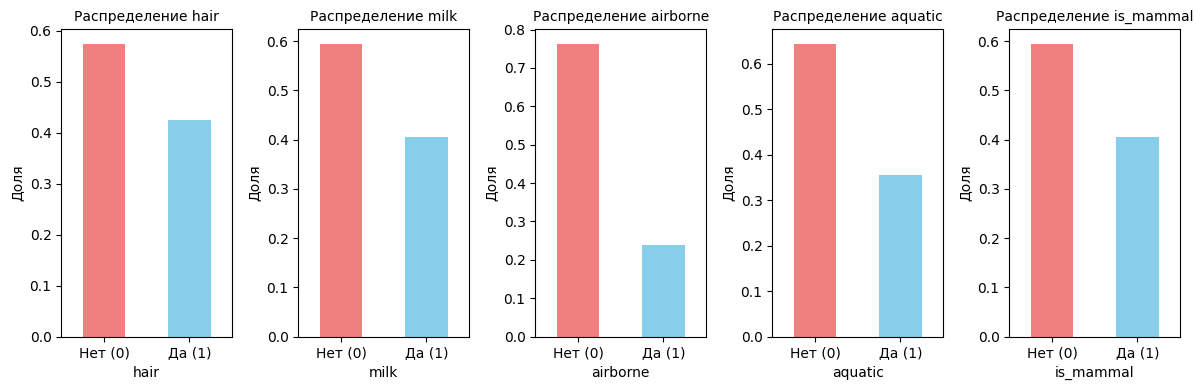

In [86]:
plt.figure(figsize=(12, 4))
features = ['hair', 'milk', 'airborne', 'aquatic', 'is_mammal']

for i, col in enumerate(features):
    plt.subplot(1, 5, i + 1)
    # Считаем частоты и строим bar plot
    data[col].value_counts(normalize=True).sort_index().plot(kind='bar', color=['lightcoral', 'skyblue'])
    plt.title(f'Распределение {col}', fontsize=10)
    plt.xticks([0, 1], ['Нет (0)', 'Да (1)'], rotation=0)
    plt.ylabel('Доля')

plt.tight_layout()
plt.show()

## Корреляции признаков

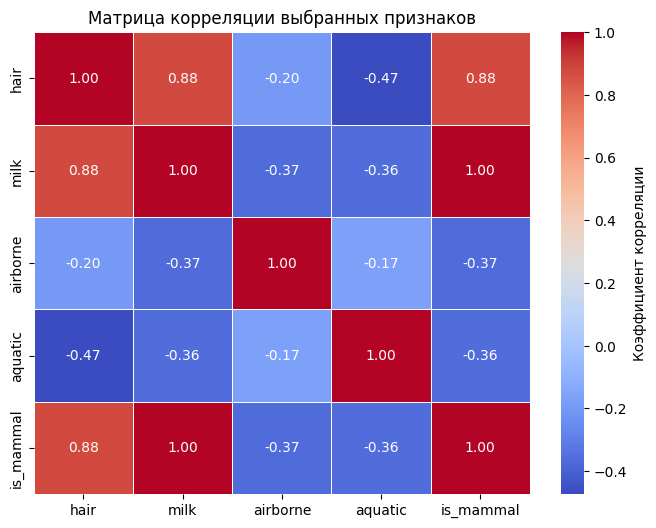

In [ ]:
corr_matrix = data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=.5, cbar_kws={'label': 'Коэффициент корреляции'})
plt.title('Матрица корреляции выбранных признаков')
plt.show()

## Зависимости

is_mammal по признаку milk - молоко — определяющий признак млекопитающих. \
is_mammal по признаку hair - шерсть — еще один ключевой признак млекопитающих. \
is_mammal по признаку airborne - большинство млекопитающих не летают (кроме летучих мышей) \
is_mammal по признаку aquatic - некоторые млекопитающие водные, но это не общий признак. \

milk и hair - is_manmal: наличие молока и шерсти — ключевые признаки млекопитающих. \
is_manmal - airborne: млекопитающие редко летают (исключение — летучие мыши). \
is_manmal - aquatic: млекопитающие редко живут в воде (исключение — киты, дельфины).

## Структура

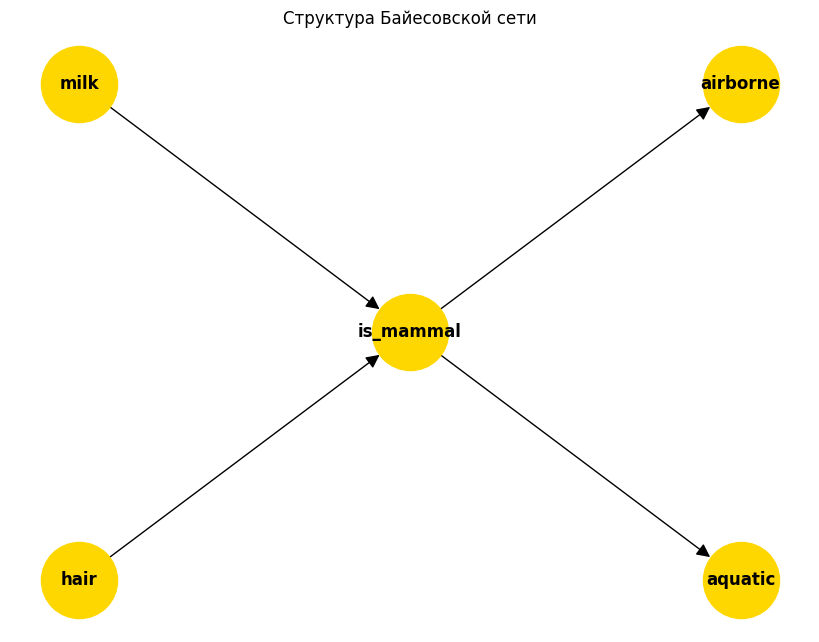

In [88]:
edges = [
    ('milk', 'is_mammal'),
    ('hair', 'is_mammal'),
    ('is_mammal', 'airborne'),
    ('is_mammal', 'aquatic')
]

G = nx.DiGraph()
G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
pos = {'milk': (0, 1), 'hair': (0, -1), 'is_mammal': (1.5, 0), 
       'airborne': (3, 1), 'aquatic': (3, -1)}
nx.draw(G, pos=pos, with_labels=True, node_size=3000, 
        node_color="gold", font_size=12, font_weight="bold", 
        arrowsize=20)
plt.title("Структура Байесовской сети")
plt.show()

## Расчет CPT

In [89]:
p_hair = data['hair'].value_counts(normalize=True).sort_index()
print(f"P(hair=0): {p_hair[0]:.3f}, P(hair=1): {p_hair[1]:.3f}")

p_milk = data['milk'].value_counts(normalize=True).sort_index()
print(f"P(milk=0): {p_milk[0]:.3f}, P(milk=1): {p_milk[1]:.3f}")

P(hair=0): 0.574, P(hair=1): 0.426
P(milk=0): 0.594, P(milk=1): 0.406


In [90]:
cpt_mammal = data.groupby(['milk', 'hair'])['is_mammal'].value_counts(normalize=True)
print("\nCPT: P(is_mammal | hair, milk)")
print(cpt_mammal)


CPT: P(is_mammal | hair, milk)
milk  hair  is_mammal
0     0     0            1.0
      1     0            1.0
1     0     1            1.0
      1     1            1.0
Name: proportion, dtype: float64


In [91]:
cpt_airborne = data.groupby('is_mammal')['airborne'].value_counts(normalize=True)
print("\nCPT: P(airborne | is_mammal)")
print(cpt_airborne)


CPT: P(airborne | is_mammal)
is_mammal  airborne
0          0           0.633333
           1           0.366667
1          0           0.951220
           1           0.048780
Name: proportion, dtype: float64


In [92]:
cpt_aquatic = data.groupby('is_mammal')['aquatic'].value_counts(normalize=True)
print("\nCPT: P(aquatic | is_mammal)")
print(cpt_aquatic)


CPT: P(aquatic | is_mammal)
is_mammal  aquatic
0          0          0.500000
           1          0.500000
1          0          0.853659
           1          0.146341
Name: proportion, dtype: float64


## Расчет Условных Вероятностей

In [ ]:
def calculate_conditional_probabilities(df):
    features = ['hair', 'milk', 'airborne', 'aquatic']
    combinations = list(product([0, 1], repeat=len(features)))
    
    cpt = {}
    
    for combo in combinations:
        hair, milk, airborne, aquatic = combo
        
        mask = (
            (df['hair'] == hair) & 
            (df['milk'] == milk) & 
            (df['airborne'] == airborne) & 
            (df['aquatic'] == aquatic)
        )
        
        subset = df[mask]
        
        if len(subset) > 0:
            prob_mammal = subset['is_mammal'].mean()
            count = len(subset)
            
            cpt[combo] = {
                'hair': hair,
                'milk': milk, 
                'airborne': airborne,
                'aquatic': aquatic,
                'P(is_mammal=1)': prob_mammal,
                'count': count,
                'P(is_mammal=0)': 1 - prob_mammal
            }
    
    return pd.DataFrame(cpt.values())


## Создание таблицы условных вероятностей

In [94]:
cpt_table = calculate_conditional_probabilities(data)
cpt_table_sorted = cpt_table.sort_values(['hair', 'milk', 'airborne', 'aquatic'])

print("Таблица условных вероятностей P(is_mammal | hair, milk, airborne, aquatic)")
cpt_table_sorted

Таблица условных вероятностей P(is_mammal | hair, milk, airborne, aquatic)


,hair,milk,airborne,aquatic,P(is_mammal=1),count,P(is_mammal=0)
0,0,0,0,0,0.0,13,1.0
1,0,0,0,1,0.0,25,1.0
2,0,0,1,0,0.0,13,1.0
3,0,0,1,1,0.0,5,1.0
4,0,1,0,1,1.0,2,0.0
5,1,0,1,0,0.0,4,1.0
6,1,1,0,0,1.0,33,0.0
7,1,1,0,1,1.0,4,0.0
8,1,1,1,0,1.0,2,0.0


## Маргинальные вероятности отдельных признаков

In [95]:
marginal_probs = {
    'P(is_mammal=1)': data['is_mammal'].mean(),
    'P(hair=1)': data['hair'].mean(),
    'P(milk=1)': data['milk'].mean(),
    'P(airborne=1)': data['airborne'].mean(),
    'P(aquatic=1)': data['aquatic'].mean()
}

marginal_df = pd.DataFrame(list(marginal_probs.items()), columns=['Вероятность', 'Значение'])
print("Маргинальные вероятности отдельных признаков")
marginal_df

Маргинальные вероятности отдельных признаков


,Вероятность,Значение
0,P(is_mammal=1),0.405941
1,P(hair=1),0.425743
2,P(milk=1),0.405941
3,P(airborne=1),0.237624
4,P(aquatic=1),0.356436


## Вычисление ключевых условных вероятностей

In [96]:
conditional_probs_data = []

mask1 = (data['hair'] == 1) & (data['milk'] == 1)
if mask1.sum() > 0:
    prob1 = data[mask1]['is_mammal'].mean()
    conditional_probs_data.append({
        'Условия': 'hair=1, milk=1',
        'P(is_mammal=1)': prob1,
        'Интерпретация': 'Высокая вероятность: шерсть и молоко - ключевые признаки млекопитающих'
    })

mask2 = (data['hair'] == 0) & (data['milk'] == 0)
if mask2.sum() > 0:
    prob2 = data[mask2]['is_mammal'].mean()
    conditional_probs_data.append({
        'Условия': 'hair=0, milk=0', 
        'P(is_mammal=1)': prob2,
        'Интерпретация': 'Очень низкая: отсутствие обоих ключевых признаков'
    })

mask3 = (data['aquatic'] == 1) & (data['airborne'] == 0)
if mask3.sum() > 0:
    prob3 = data[mask3]['is_mammal'].mean()
    conditional_probs_data.append({
        'Условия': 'aquatic=1, airborne=0',
        'P(is_mammal=1)': prob3,
        'Интерпретация': 'Низкая: водные нелетающие - обычно рыбы, не млекопитающие'
    })

conditional_probs_df = pd.DataFrame(conditional_probs_data)
print("Ключевые условные вероятности с интерпретацией")
conditional_probs_df

Ключевые условные вероятности с интерпретацией


,Условия,P(is_mammal=1),Интерпретация
0,"hair=1, milk=1",1.000000,Высокая вероятность: шерсть и молоко - ключевы...
1,"hair=0, milk=0",0.000000,Очень низкая: отсутствие обоих ключевых признаков
2,"aquatic=1, airborne=0",0.193548,"Низкая: водные нелетающие - обычно рыбы, не мл..."


## Вывод

Построенная Байесовская сеть подтвердила биологические закономерности, показав, что наличие молока и шерсти являются определяющими признаками млекопитающих (P=1.0 при наличии обоих признаков), в то время как водный образ жизни и способность к полету оказались вторичными производными характеристиками, демонстрирующими свойство условной независимости при фиксированном статусе млекопитающего. Сеть оценила интуитивные представления, показав, что лишь 5% млекопитающих летают и 15% являются водными, что делает модель не только математически корректной, но и биологически интерпретируемой, а прозрачная структура графа позволяет легко проследить причинно-следственные связи между признаками.